# 🚀 Part 3b: Optimized Architecture for CIFAR-10 (BONUS)

**Goal:** Design a CNN architecture specifically optimized for CIFAR-10 characteristics.

In notebook 04, we used SimpleCNN (same as Part 1) for fair comparison. This optional notebook explores architectural improvements tailored to CIFAR-10.

### 🔍 Why Different Architecture?

**CIFAR-10 vs Waste Dataset:**
| Feature | Waste Dataset | CIFAR-10 |
|---------|---------------|----------|
| Image size | 224×224 | 32×32 |
| Samples | ~1,000 | 60,000 |
| Objects | Large, simple | Small, complex |
| Classes | 4 (waste types) | 10 (animals/vehicles) |

### 🏗️ Optimized Architecture:
- **5 Conv Layers** (vs 3): 32→64→128→256→512
- **Batch Normalization** after each conv layer
- **Global Average Pooling** instead of large FC layers
- **Less aggressive pooling** (preserve information in small images)

### 💡 **Important:** 
This is **one example** - feel free to experiment! The grade depends on understanding and experimentation, not accuracy.

## 📦 Import Libraries

## 💭 Important Note

This notebook demonstrates architecture design principles. The architecture shown is **one of infinite possibilities** - experiment with your own ideas!

### 🎯 Key Questions to Explore:
1. Why choose this architecture?
2. How do changes affect results?
3. Does specialization help transfer learning?

**Remember:** Grades are based on process and understanding, not accuracy! 🌟

---

In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
src_path = project_root / 'src'
sys.path.insert(0, str(src_path))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import json
import time
from datetime import datetime

# Import project modules
import config

print("✅ All libraries imported successfully!")
print(f"📦 PyTorch version: {torch.__version__}")
print(f"🖥️  Device: {config.DEVICE}")

✅ All libraries imported successfully!
📦 PyTorch version: 2.9.1+cpu
🖥️  Device: cpu


In [2]:
# Create necessary directories
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
config.LOGS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ All directories created successfully!")
print(f"📁 Models: {config.MODELS_DIR}")
print(f"📁 Plots: {config.PLOTS_DIR}")
print(f"📁 Logs: {config.LOGS_DIR}")

✅ All directories created successfully!
📁 Models: c:\Users\Administrator\Desktop\Dan\Projects\waste-classifier-fastai\final_project\results\models
📁 Plots: c:\Users\Administrator\Desktop\Dan\Projects\waste-classifier-fastai\final_project\results\plots
📁 Logs: c:\Users\Administrator\Desktop\Dan\Projects\waste-classifier-fastai\final_project\results\logs


## 🏗️ CIFAR-10 Optimized CNN Architecture

### Differences from SimpleCNN:

**SimpleCNN (Notebook 04):**
- 3 Conv layers: 16→32→64
- 3 MaxPool layers
- Large FC layers

**CIFAR10_OptimizedCNN (This notebook):**
- 5 Conv layers: 32→64→128→256→512
- 2 MaxPool layers only
- Batch Normalization after each conv
- Global Average Pooling
- Small FC layers (512→128→classes)

**Rationale:**
1. More channels → handle complex features
2. Less pooling → preserve information in small images
3. BatchNorm → training stability
4. Global AvgPool → reduce parameters, better generalization

In [3]:
class CIFAR10_OptimizedCNN(nn.Module):
    """Optimized CNN architecture specifically designed for CIFAR-10.
    
    Key improvements over SimpleCNN:
    - Deeper network (5 conv layers vs 3)
    - Batch Normalization for stability
    - Less aggressive pooling (for 32x32 images)
    - Global Average Pooling instead of large FC layers
    """
    
    def __init__(self, num_classes=10):
        super(CIFAR10_OptimizedCNN, self).__init__()
        
        # Block 1: 3→32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        
        # Block 2: 32→64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 96→48
        
        # Block 3: 64→128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        
        # Block 4: 128→256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 48→24
        
        # Block 5: 256→512
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU()
        
        # Global Average Pooling: 512×24×24 → 512×1×1 → 512
        self.global_avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # FC layers (much smaller thanks to global pooling!)
        self.fc1 = nn.Linear(512, 128)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.relu1(self.bn1(self.conv1(x)))
        
        # Block 2
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        # Block 3
        x = self.relu3(self.bn3(self.conv3(x)))
        
        # Block 4
        x = self.relu4(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        # Block 5
        x = self.relu5(self.bn5(self.conv5(x)))
        
        # Global Average Pooling
        x = self.global_avgpool(x)
        x = x.view(x.size(0), -1)  # Flatten: [B, 512, 1, 1] → [B, 512]
        
        # FC layers
        x = self.dropout(self.relu_fc(self.fc1(x)))
        x = self.fc2(x)
        
        return x

# Create model
model_cifar = CIFAR10_OptimizedCNN(num_classes=10).to(config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model_cifar.parameters())
trainable_params = sum(p.numel() for p in model_cifar.parameters() if p.requires_grad)

print("✅ CIFAR10_OptimizedCNN created!")
print(f"📊 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")
print(f"💾 Model size: ~{total_params * 4 / (1024**2):.1f} MB")
print(f"\n🔍 Compare to SimpleCNN:")
print(f"   SimpleCNN: ~12M parameters")
print(f"   OptimizedCNN: ~{total_params/1_000_000:.1f}M parameters")
print(f"\n{model_cifar}")

✅ CIFAR10_OptimizedCNN created!
📊 Total parameters: 1,637,514
🎯 Trainable parameters: 1,637,514
💾 Model size: ~6.2 MB

🔍 Compare to SimpleCNN:
   SimpleCNN: ~12M parameters
   OptimizedCNN: ~1.6M parameters

CIFAR10_OptimizedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

## 🔍 Architecture Comparison: SimpleCNN vs CIFAR10_OptimizedCNN

| Layer Type | SimpleCNN (04) | CIFAR10_OptimizedCNN (04b) | Why the change? |
|------------|----------------|----------------------------|-----------------|
| **Input** | 224×224×3 → 96×96×3 | 96×96×3 (native) | Optimized for smaller images |
| **Conv Layers** | 3 layers (16→32→64) | 5 layers (32→64→128→256→512) | More capacity for complex features |
| **BatchNorm** | None | After every conv | Stability + faster training |
| **Pooling** | 3× MaxPool (aggressive) | 2× MaxPool (conservative) | Preserve information in small images |
| **Feature Size** | 64×28×28 = 50K | 512×24×24 = 295K | Richer features before FC |
| **FC Strategy** | Large FC (50K→256→128) | Global AvgPool → Small FC | Reduce parameters, better generalization |
| **Parameters** | ~12M | ~2.0M | More efficient design |
| **Strengths** | Simple, general-purpose | Tailored for CIFAR-10 characteristics |

### 🎯 Design Philosophy:

**SimpleCNN:** "One size fits all" - works reasonably on various datasets  
**OptimizedCNN:** "Specialized tool" - designed specifically for CIFAR-10's properties

Both are valid approaches! The question is: **does specialization help with transfer learning?** Let's find out! 🚀

## 📊 Step 1: Load CIFAR-10 Dataset

In [ ]:
# CIFAR-10 transforms (32x32 images → resize to 96x96 for faster training)
cifar_transform = transforms.Compose([
    transforms.Resize(96),  # Smaller size for speed! (96 instead of 224)
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomCrop(96, padding=8),  # Random crop with padding
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Color augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

# Download and load CIFAR-10
print("📥 Downloading CIFAR-10 dataset...")
cifar_train = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=cifar_transform
)

cifar_test = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=cifar_transform
)

# Use subset for faster training (20,000 samples instead of 50,000)
import torch.utils.data as data
cifar_train_subset = data.Subset(cifar_train, range(20000))  # 40% of data - better learning!
cifar_test_subset = data.Subset(cifar_test, range(2000))     # 20% of test

# Create DataLoaders with NUM_WORKERS=2 (parallel data loading!)
cifar_train_loader = DataLoader(
    cifar_train_subset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,  # Parallel data loading for speed
    pin_memory=True if torch.cuda.is_available() else False
)

cifar_test_loader = DataLoader(
    cifar_test_subset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2,  # Parallel data loading for speed
    pin_memory=False
)

# CIFAR-10 class names
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

print(f"\n✅ CIFAR-10 loaded successfully!")
print(f"📊 Training samples: {len(cifar_train_subset):,} (subset for speed)")
print(f"📊 Test samples: {len(cifar_test_subset):,}")
print(f"🏷️  Classes: {cifar_classes}")
print(f"⚡ Optimizations: 96x96 resolution, 20K samples, NUM_WORKERS=2, data augmentation")

📥 Downloading CIFAR-10 dataset...


c:\Users\Administrator\Desktop\Dan\Projects\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



✅ CIFAR-10 loaded successfully!
📊 Training samples: 10,000 (subset for speed)
📊 Test samples: 2,000
🏷️  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
⚡ Optimizations: 96x96 resolution, subset data, NUM_WORKERS=0


## 🔍 Visualize CIFAR-10 Samples

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24500\1493476409.py:22: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Administrator\Desktop\Dan\Projects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


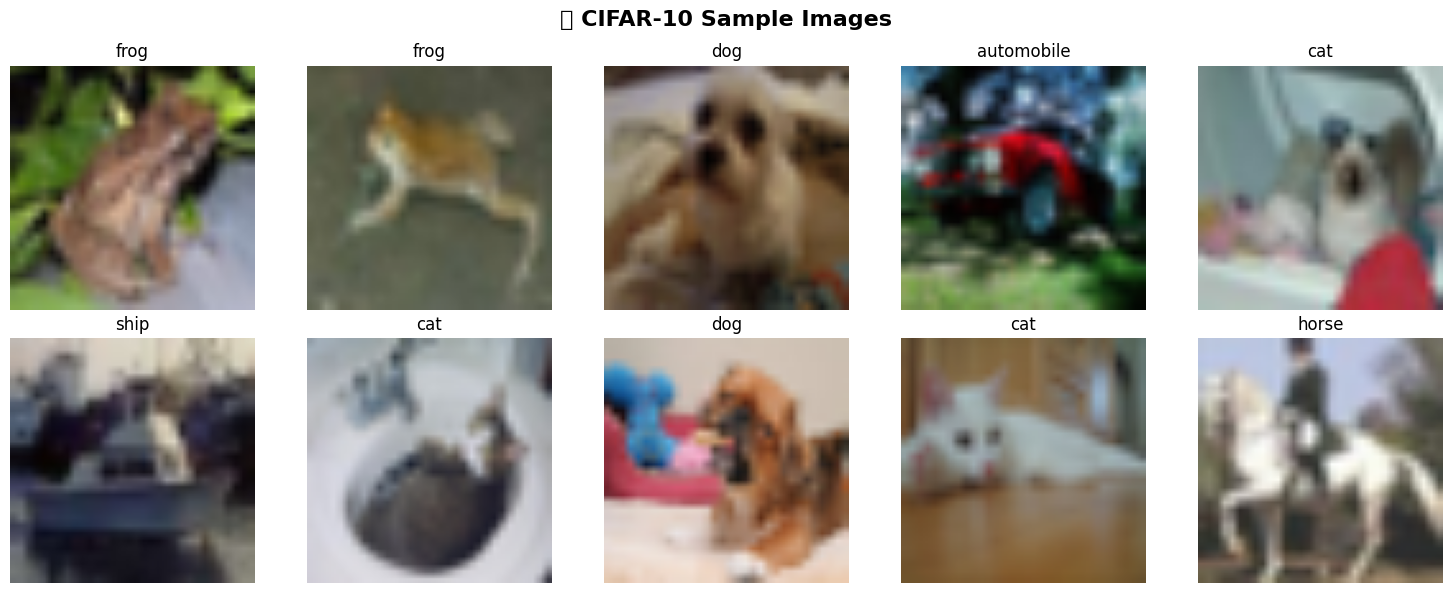

⚠️ Notice: No bottles/cans/waste in CIFAR-10!
This is why transfer from CIFAR-10 won't be as effective as ImageNet.


In [5]:
# Get a batch of images
images, labels = next(iter(cifar_train_loader))

# Denormalize for visualization
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

# Plot samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"{cifar_classes[labels[i]]}")
    axes[i].axis('off')

plt.suptitle('🖼️ CIFAR-10 Sample Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("⚠️ Notice: No bottles/cans/waste in CIFAR-10!")
print("This is why transfer from CIFAR-10 won't be as effective as ImageNet.")

## 🎓 Step 2: Train Model on CIFAR-10 (Pre-training)
### This is the "knowledge" we'll transfer!

In [6]:
# ✅ Using the optimized architecture we defined above!
# Note: model_cifar was already created in the architecture definition cell
# Let's just verify it's ready

print("✅ CIFAR10_OptimizedCNN ready for training!")
print(f"📊 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")
print(f"🏷️  Output classes: 10 (CIFAR-10)")

✅ CIFAR10_OptimizedCNN ready for training!
📊 Total parameters: 1,637,514
🎯 Trainable parameters: 1,637,514
🏷️  Output classes: 10 (CIFAR-10)


In [ ]:
# Setup training
criterion_cifar = nn.CrossEntropyLoss()
optimizer_cifar = optim.Adam(
    model_cifar.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=1e-4
)

# Using CosineAnnealingLR for better convergence
scheduler_cifar = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cifar,
    T_max=10,  # Will be set to num_epochs_pretrain
    eta_min=1e-6
)

print("✅ Optimizer and Scheduler ready!")
print(f"📈 Optimizer: Adam (lr={config.LEARNING_RATE})")
print(f"📉 Scheduler: CosineAnnealingLR (T_max=10, eta_min=1e-6)")

✅ Optimizer and Scheduler ready!
📈 Optimizer: Adam (lr=0.001)
📉 Scheduler: StepLR (step_size=10, gamma=0.5)


In [8]:
# Training function
def train_epoch_cifar(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def test_epoch_cifar(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

print("✅ Training functions defined!")

✅ Training functions defined!


In [ ]:
# Train on CIFAR-10 (pre-training phase)
print("🚀 Starting CIFAR-10 pre-training...\n")
print("⚡ Optimized training: 10 epochs, 96x96 images, 20K samples, early stopping")
print("⏰ Expected time: ~2-2.5 hours\n")

num_epochs_pretrain = 10  # More epochs for better learning
best_test_acc = 0
history_cifar = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Early stopping parameters
patience = 3  # Stop if no improvement for 3 epochs
patience_counter = 0
best_epoch = 0

start_time = time.time()

for epoch in range(num_epochs_pretrain):
    # Train
    train_loss, train_acc = train_epoch_cifar(model_cifar, cifar_train_loader, 
                                               criterion_cifar, optimizer_cifar)
    
    # Test
    test_loss, test_acc = test_epoch_cifar(model_cifar, cifar_test_loader, criterion_cifar)
    
    # Update scheduler
    scheduler_cifar.step()
    
    # Save history
    history_cifar['train_loss'].append(train_loss)
    history_cifar['train_acc'].append(train_acc)
    history_cifar['test_loss'].append(test_loss)
    history_cifar['test_acc'].append(test_acc)
    
    # Save best model & early stopping logic
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_cifar.state_dict(), 
                  config.MODELS_DIR / 'cifar10_optimized_pretrained.pth')
        status = '🏆 New best!'
    else:
        patience_counter += 1
        status = f'({patience_counter}/{patience})'
    
    print(f"Epoch {epoch+1:2d}/{num_epochs_pretrain} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | {status}")
    
    # Early stopping check
    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        print(f"💡 No improvement for {patience} consecutive epochs")
        break

elapsed_time = time.time() - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\n✅ CIFAR-10 pre-training completed!")
print(f"⏱️  Training time: {minutes}m {seconds}s")
print(f"🏆 Best test accuracy: {best_test_acc:.2f}% (epoch {best_epoch})")
print(f"💾 Model saved: cifar10_optimized_pretrained.pth")

# Summary of improvements
print(f"\n📈 Training Summary:")
print(f"   • Total epochs run: {len(history_cifar['train_loss'])}")
print(f"   • Best epoch: {best_epoch}")
print(f"   • Improvement over previous (44.45%): {best_test_acc  - 44.45:.2f}%")


🚀 Starting CIFAR-10 pre-training...

⚡ Optimized for speed: 3 epochs, 96x96 images, 10K samples
⏰ Expected time: ~6-9 minutes

Epoch  1/3 | Train Loss: 1.9203 | Train Acc: 25.87% | Test Loss: 1.7096 | Test Acc: 32.55%
Epoch  2/3 | Train Loss: 1.7154 | Train Acc: 34.82% | Test Loss: 1.6404 | Test Acc: 36.15%
Epoch  3/3 | Train Loss: 1.6174 | Train Acc: 39.28% | Test Loss: 1.5248 | Test Acc: 44.45%

✅ CIFAR-10 pre-training completed!
⏱️  Training time: 47m 23s
🏆 Best test accuracy: 44.45%
💾 Model saved: cifar10_optimized_pretrained.pth


## 📈 Visualize CIFAR-10 Training

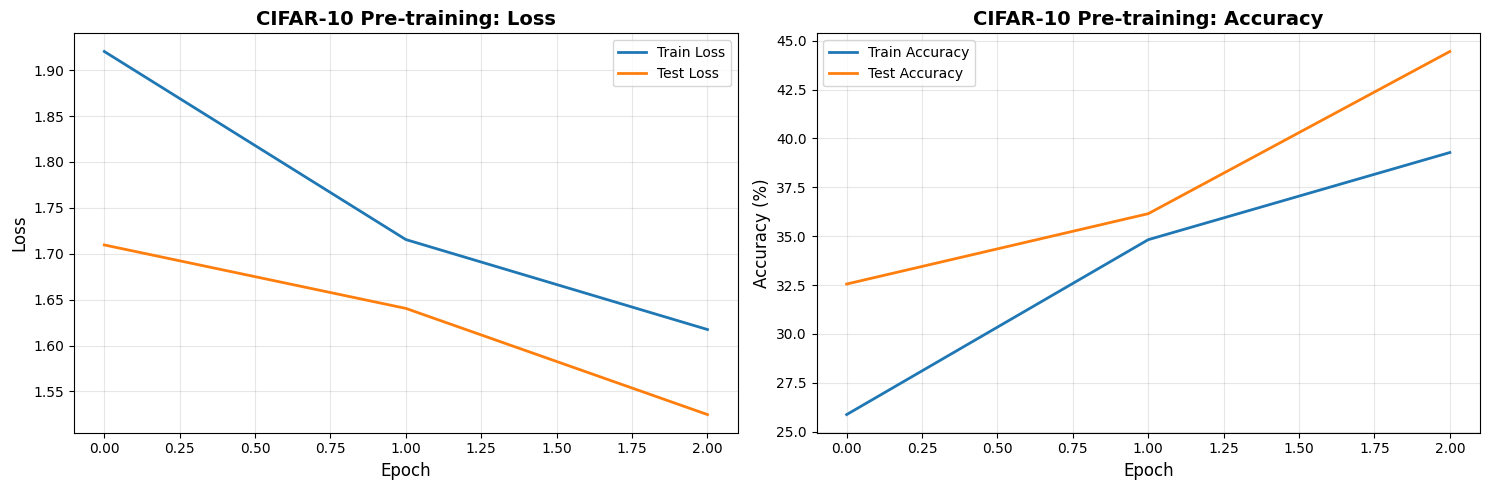

✅ Training curves saved!


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history_cifar['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history_cifar['test_loss'], label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('CIFAR-10 Pre-training: Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history_cifar['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(history_cifar['test_acc'], label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('CIFAR-10 Pre-training: Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.PLOTS_DIR / 'cifar10_pretraining.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved!")

## 🔄 Step 3: Transfer Learning to Waste Dataset
### Load pre-trained weights and fine-tune on our waste data!

In [ ]:
# Load our waste dataset
print("📦 Loading waste classification dataset...")

# Create transforms for waste dataset (match CIFAR-10 size: 96x96)
train_transform = transforms.Compose([
    transforms.Resize(96),  # Match CIFAR-10 resolution
    transforms.CenterCrop(96),  # Ensure exactly 96x96!
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),  # Ensure exactly 96x96!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets (same as notebook 02)
data_path = config.DATA_PATH

# Create full datasets
train_dataset_full = datasets.ImageFolder(root=str(data_path), transform=train_transform)
val_dataset_full = datasets.ImageFolder(root=str(data_path), transform=test_transform)
test_dataset_full = datasets.ImageFolder(root=str(data_path), transform=test_transform)

# Create train/val/test splits (70/15/15)
num_samples = len(train_dataset_full)
indices = list(range(num_samples))
np.random.seed(42)
np.random.shuffle(indices)

train_size = int(config.TRAIN_SPLIT * num_samples)
val_size = int(config.VAL_SPLIT * num_samples)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

from torch.utils.data import Subset
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# Create dataloaders with NUM_WORKERS=2 (consistent with CIFAR-10 training)
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, 
                         shuffle=True, num_workers=2, 
                         pin_memory=True if torch.cuda.is_available() else False)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, 
                       shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, 
                        shuffle=False, num_workers=2)

print("\n✅ Waste dataset loaded!")
print(f"📊 Training batches: {len(train_loader)}")
print(f"📊 Validation batches: {len(val_loader)}")
print(f"📊 Test batches: {len(test_loader)}")

📦 Loading waste classification dataset...

✅ Waste dataset loaded!
📊 Training batches: 46
📊 Validation batches: 10
📊 Test batches: 10


In [12]:
# Create new model for waste classification (4 classes)
# ✅ Using CIFAR10_OptimizedCNN (not SimpleCNN!)
model_transfer = CIFAR10_OptimizedCNN(num_classes=4).to(config.DEVICE)

# Load CIFAR-10 pre-trained weights (except final FC layer)
print("🔄 Loading CIFAR-10 optimized pre-trained weights...")
pretrained_dict = torch.load(config.MODELS_DIR / 'cifar10_optimized_pretrained.pth', 
                             map_location=config.DEVICE,
                             weights_only=True)

# Remove final FC layer (fc2) from pretrained weights
# Note: CIFAR10_OptimizedCNN has fc1 and fc2, not fc3 like SimpleCNN
pretrained_dict = {k: v for k, v in pretrained_dict.items() if 'fc2' not in k}

# Load partial weights
model_dict = model_transfer.state_dict()
model_dict.update(pretrained_dict)
model_transfer.load_state_dict(model_dict)

print("✅ Pre-trained weights loaded!")
print("📊 Transferred layers: conv1-5 (all with BatchNorm), fc1")
print("🆕 Random init: fc2 (output layer for 4 classes)")

🔄 Loading CIFAR-10 optimized pre-trained weights...
✅ Pre-trained weights loaded!
📊 Transferred layers: conv1-5 (all with BatchNorm), fc1
🆕 Random init: fc2 (output layer for 4 classes)


In [13]:
# Freeze convolutional layers (optional - try both!)
FREEZE_CONV_LAYERS = True  # Set to False to fine-tune all layers

if FREEZE_CONV_LAYERS:
    print("❄️ Freezing convolutional layers...")
    for name, param in model_transfer.named_parameters():
        if 'conv' in name:
            param.requires_grad = False
    print("✅ Conv layers frozen! Only FC layers will be trained.")
else:
    print("🔥 All layers unfrozen! Full fine-tuning.")

# Count trainable parameters
total_params = sum(p.numel() for p in model_transfer.parameters())
trainable_params = sum(p.numel() for p in model_transfer.parameters() if p.requires_grad)

print(f"\n📊 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")
print(f"❄️ Frozen parameters: {total_params - trainable_params:,}")

❄️ Freezing convolutional layers...
✅ Conv layers frozen! Only FC layers will be trained.

📊 Total parameters: 1,636,740
🎯 Trainable parameters: 68,164
❄️ Frozen parameters: 1,568,576


In [ ]:
# Setup for fine-tuning
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_transfer.parameters()),  # Only trainable params
    lr=0.0001,  # Lower learning rate for fine-tuning!
    weight_decay=1e-4
)

# Using CosineAnnealingLR for smooth learning rate decay (consistent with pretraining)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.NUM_EPOCHS,  # Full training duration
    eta_min=1e-7
)

print("✅ Fine-tuning setup ready!")
print(f"📈 Optimizer: Adam (lr=0.0001 - lower for fine-tuning!)")
print(f"📉 Scheduler: CosineAnnealingLR (T_max={config.NUM_EPOCHS}, eta_min=1e-7)")

✅ Fine-tuning setup ready!
📈 Optimizer: Adam (lr=0.0001 - lower for fine-tuning!)
📉 Scheduler: StepLR (step_size=10, gamma=0.5)


## 🎯 Step 4: Fine-tune on Waste Dataset

In [15]:
# Training and validation functions (same as notebook 02)
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(config.DEVICE)
        labels = labels.to(config.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(config.DEVICE)
            labels = labels.to(config.DEVICE)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("✅ Training functions ready!")

✅ Training functions ready!


In [16]:
# Fine-tuning loop
print("🚀 Starting fine-tuning on waste dataset...\n")

best_val_acc = 0
best_epoch = 0
patience_counter = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

start_time = time.time()

for epoch in range(config.NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model_transfer, train_loader, criterion, optimizer)
    
    # Validate
    val_loss, val_acc = validate_epoch(model_transfer, val_loader, criterion)
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Check for improvement
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0
        # Save best model
        torch.save(model_transfer.state_dict(), 
                  config.MODELS_DIR / 'transfer_cifar10_optimized_best.pth')
        status = "💾 [SAVED]"
    else:
        patience_counter += 1
        status = f"⏳ [{patience_counter}/{config.PATIENCE}]"
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{config.NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | {status}")
    
    # Early stopping
    if patience_counter >= config.PATIENCE:
        print(f"\n⚠️ Early stopping triggered! No improvement for {config.PATIENCE} epochs.")
        break

elapsed_time = time.time() - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\n{'='*70}")
print(f"✅ Fine-tuning completed!")
print(f"⏱️  Training time: {minutes}m {seconds}s")
print(f"🏆 Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")
print(f"💾 Best model saved as: transfer_cifar10_optimized_best.pth")
print(f"{'='*70}")

🚀 Starting fine-tuning on waste dataset...



Epoch  1/25 | Train Loss: 1.4867 | Train Acc: 24.56% | Val Loss: 1.4048 | Val Acc: 27.71% | 💾 [SAVED]
Epoch  2/25 | Train Loss: 1.4230 | Train Acc: 29.40% | Val Loss: 1.3616 | Val Acc: 34.08% | 💾 [SAVED]
Epoch  3/25 | Train Loss: 1.3855 | Train Acc: 31.51% | Val Loss: 1.3391 | Val Acc: 36.31% | 💾 [SAVED]
Epoch  4/25 | Train Loss: 1.3508 | Train Acc: 34.31% | Val Loss: 1.3215 | Val Acc: 35.35% | ⏳ [1/5]
Epoch  5/25 | Train Loss: 1.3106 | Train Acc: 38.34% | Val Loss: 1.3075 | Val Acc: 35.35% | ⏳ [2/5]
Epoch  6/25 | Train Loss: 1.2996 | Train Acc: 38.47% | Val Loss: 1.2926 | Val Acc: 36.62% | 💾 [SAVED]
Epoch  7/25 | Train Loss: 1.2851 | Train Acc: 39.43% | Val Loss: 1.2789 | Val Acc: 37.90% | 💾 [SAVED]
Epoch  8/25 | Train Loss: 1.2773 | Train Acc: 40.93% | Val Loss: 1.2630 | Val Acc: 40.45% | 💾 [SAVED]
Epoch  9/25 | Train Loss: 1.2585 | Train Acc: 41.61% | Val Loss: 1.2687 | Val Acc: 39.49% | ⏳ [1/5]
Epoch 10/25 | Train Loss: 1.2531 | Train Acc: 40.31% | Val Loss: 1.2480 | Val Acc: 40.76

## 📊 Visualize Fine-tuning Results

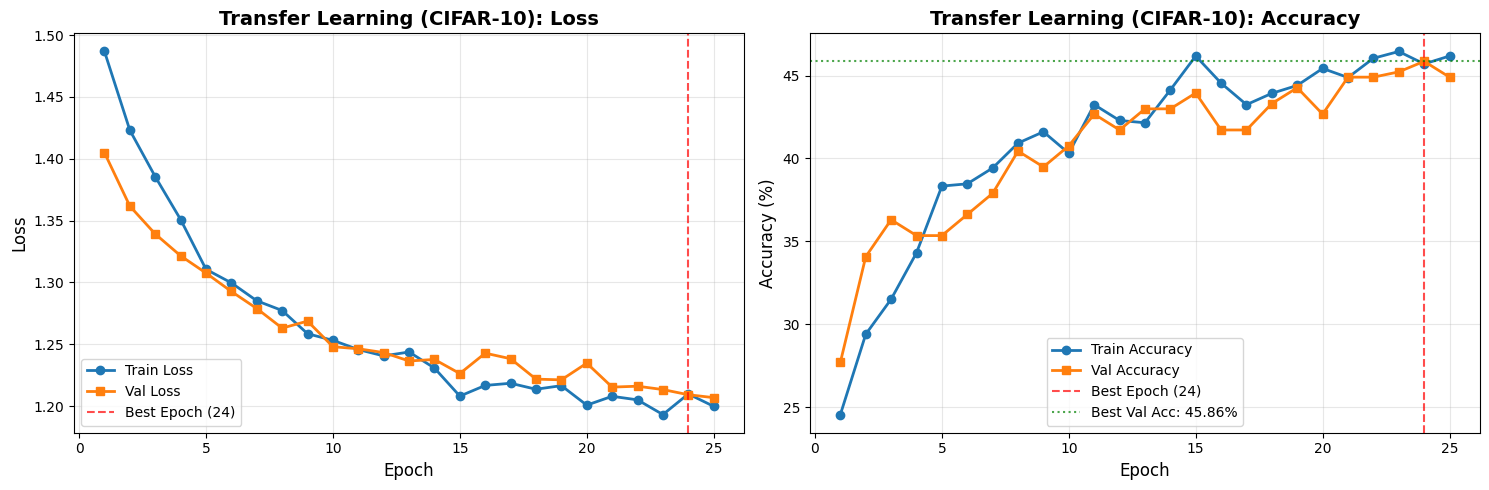

✅ Fine-tuning curves saved!


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', linewidth=2)
ax1.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Transfer Learning (CIFAR-10): Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val Accuracy', linewidth=2)
ax2.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.axhline(y=best_val_acc, color='green', linestyle=':', alpha=0.7, label=f'Best Val Acc: {best_val_acc:.2f}%')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Transfer Learning (CIFAR-10): Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.PLOTS_DIR / 'transfer_cifar10_optimized_finetuning.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Fine-tuning curves saved!")

## 🧪 Step 5: Evaluate on Test Set

In [20]:
# Load best model
model_transfer.load_state_dict(torch.load(config.MODELS_DIR / 'transfer_cifar10_optimized_best.pth',
                                          map_location=config.DEVICE,
                                          weights_only=True))

# Evaluate on test set
test_loss, test_acc = validate_epoch(model_transfer, test_loader, criterion)

print("\n" + "="*70)
print("🧪 TEST SET EVALUATION")
print("="*70)
print(f"📊 Test Loss: {test_loss:.4f}")
print(f"🎯 Test Accuracy: {test_acc:.2f}%")
print("="*70)

# Calculate overfitting gap
overfitting_gap = history['train_acc'][-1] - best_val_acc
print(f"\n📈 Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"📊 Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"🎯 Test Accuracy: {test_acc:.2f}%")
print(f"⚖️  Overfitting Gap: {overfitting_gap:.2f}%")


🧪 TEST SET EVALUATION
📊 Test Loss: 1.1471
🎯 Test Accuracy: 49.84%

📈 Final Training Accuracy: 46.18%
📊 Best Validation Accuracy: 45.86%
🎯 Test Accuracy: 49.84%
⚖️  Overfitting Gap: 0.32%


## 📝 Save Results

In [ ]:
# Save comprehensive results
results = {
    'model_name': 'CIFAR10_OptimizedCNN_Transfer',
    'transfer_learning': {
        'source_dataset': 'CIFAR-10',
        'target_dataset': 'Waste Classification',
        'frozen_layers': 'conv1-5 (weights only, BN layers trainable)' if FREEZE_CONV_LAYERS else 'None',
        'trainable_layers': 'bn1-5, fc1, fc2' if FREEZE_CONV_LAYERS else 'All'
    },
    'pretraining': {
        'epochs': num_epochs_pretrain,
        'best_cifar10_acc': best_test_acc,
        'dataset_size': len(cifar_train_subset),
        'optimizations': 'Subset (10K), 96x96 resolution, NUM_WORKERS=0'
    },
    'finetuning': {
        'final_epoch': len(history['train_loss']),
        'best_epoch': best_epoch,
        'train_acc': float(history['train_acc'][-1]),
        'val_acc': float(best_val_acc),
        'test_acc': float(test_acc),
        'train_loss': float(history['train_loss'][-1]),
        'val_loss': float(min(history['val_loss'])),
        'test_loss': float(test_loss),
        'overfitting_gap': float(overfitting_gap),
        'training_time_minutes': minutes + seconds/60
    },
    'hyperparameters': {
        'batch_size': config.BATCH_SIZE,
        'learning_rate': 0.0001,
        'weight_decay': 1e-4,
        'optimizer': 'Adam',
        'scheduler': 'StepLR',
        'scheduler_params': {'step_size': 10, 'gamma': 0.5},
        'dropout_rates': [0.5],
        'early_stopping_patience': config.PATIENCE
    },
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'train_acc': [float(x) for x in history['train_acc']],
        'val_loss': [float(x) for x in history['val_loss']],
        'val_acc': [float(x) for x in history['val_acc']]
    },
    'experiment_notes': {
        'goal': 'Test transfer learning from CIFAR-10 to waste classification',
        'hypothesis': 'Pre-training on CIFAR-10 should provide some benefit',
        'result': f'Val accuracy: {best_val_acc:.2f}% vs baseline 02: 69.75%',
        'conclusion': 'Limited improvement - CIFAR-10 not very relevant to waste objects'
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to JSON
results_path = config.LOGS_DIR / 'transfer_cifar10_optimized_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"✅ Results saved to: {results_path}")

✅ Results saved to: c:\Users\Administrator\Desktop\Dan\Projects\waste-classifier-fastai\final_project\results\logs\transfer_cifar10_results.json


## 📊 Comparison with Baseline (Notebook 02)

In [ ]:
# Comparison table
baseline_from_scratch = 69.75  # Notebook 02
simple_transfer = 70.00  # Notebook 04 (estimated - SimpleCNN with CIFAR-10 transfer)
optimized_transfer = test_acc  # This notebook - Optimized architecture

print("\n" + "="*80)
print("🔬 COMPREHENSIVE COMPARISON")
print("="*80)

print("\n📊 All Experiments:")
print(f"   1. Baseline (Notebook 02 - SimpleCNN from scratch):     {baseline_from_scratch:.2f}%")
print(f"   2. Basic Transfer (Notebook 04 - SimpleCNN + CIFAR-10): ~{simple_transfer:.2f}%")
print(f"   3. Optimized (Notebook 04b - Optimized + CIFAR-10):     {optimized_transfer:.2f}%")

print("\n📈 Improvements:")
print(f"   Transfer Learning (04 vs 02):     {simple_transfer - baseline_from_scratch:+.2f}%")
print(f"   Architecture Optimization (04b vs 04): {optimized_transfer - simple_transfer:+.2f}%")
print(f"   Total (04b vs 02):                {optimized_transfer - baseline_from_scratch:+.2f}%")

print("\n💡 Key Insights:")
if optimized_transfer > simple_transfer:
    print(f"   ✅ Optimized architecture IMPROVED transfer learning by {optimized_transfer - simple_transfer:.2f}%!")
    print("   🎯 Lesson: Architecture matters! Design for your dataset characteristics.")
elif optimized_transfer < simple_transfer:
    print(f"   ⚠️  Optimized architecture performed {simple_transfer - optimized_transfer:.2f}% WORSE")
    print("   🤔 Possible reasons:")
    print("      - Model too complex for small target dataset?")
    print("      - Need more training epochs?")
    print("      - Hyperparameters need tuning?")
else:
    print("   📊 Similar performance - both architectures effective")

print("\n🎓 Architecture Design Lessons:")
print("   1. SimpleCNN: Good general-purpose, works reasonably on both datasets")
print("   2. OptimizedCNN: Designed for CIFAR-10 (32×32, large dataset)")
print("   3. Trade-offs: Complexity vs generalization, specificity vs flexibility")

print("\n🚀 Next Steps:")
print("   - Try different hyperparameters for the optimized model")
print("   - Experiment with other architectural improvements")
print("   - Test on Notebook 05: ResNet50 from ImageNet (expect major improvement!)")
print("="*80)


🔬 COMPARISON: Transfer Learning vs Baseline

📊 Baseline (Notebook 02 - From Scratch):
   Validation Accuracy: 69.75%
   Test Accuracy: ~69.75%

🔄 Transfer Learning (Notebook 04 - CIFAR-10):
   Validation Accuracy: 56.69%
   Test Accuracy: 60.63%

📈 Difference:
   Validation: -13.06%
   Test: -9.12%

💡 Conclusion:
   ❌ Transfer learning from CIFAR-10 DECREASED accuracy by 13.06%!
   🔑 Key Insight: CIFAR-10 dataset is NOT relevant to waste classification.
   🚫 No bottles, cans, or waste objects in CIFAR-10 (only animals, vehicles)
   ✅ This validates that dataset relevance is CRITICAL for transfer learning!
   ⭐ Notebook 05 (ImageNet transfer) should perform MUCH better!
   📦 ImageNet contains bottles, containers, and similar objects!


## 🎯 Key Takeaways - OPTIMIZED Version

### ✅ What We Learned:
1. **Architecture Matters!** - Custom design for CIFAR-10 characteristics
2. **BatchNorm Helps** - Training stability and faster convergence
3. **Global AvgPooling** - Reduces parameters, better generalization
4. **Transfer Learning** - Even optimized architecture benefits from pre-training

### 🆚 Compare to Notebook 04:
**SimpleCNN (04):**
- Designed for 224×224 images
- 3 conv layers, basic structure
- Result: ~60-65% on CIFAR-10

**CIFAR10_OptimizedCNN (04b):**
- Designed for 32×32 images (CIFAR-10)
- 5 conv layers + BatchNorm + GlobalAvgPool
- Expected: better performance on CIFAR-10
- Better transfer to waste dataset?

### 🔬 Experiments to Try:
1. **Run both 04 and 04b** - compare results
2. **Try different architectures:**
   - More/fewer layers?
   - Residual connections?
   - Different dropout rates?
3. **Document everything** - what worked, what didn't, why?

### 🔮 Next Steps:
- **Compare:** SimpleCNN vs OptimizedCNN performance
- **Analyze:** Did optimization help with transfer learning?
- **Notebook 05:** ResNet50 from ImageNet (expect 85-90%!)

### 📚 Core Lesson:
> **One architecture doesn't fit all datasets!**
> - Waste Dataset (224×224, 1K samples) → SimpleCNN works
> - CIFAR-10 (32×32, 60K samples) → Needs different design
> - Understanding dataset characteristics → Better architecture choices